In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("pnkjgpt/butterfly-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 426M/426M [00:20<00:00, 21.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4):
['Train']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the path to the main training directory
train_dir = os.path.join(path, 'Train')

# FIX: Use '/content/' instead of 'base_path' (which was /kaggle/input)
# '/content/' is writable in Google Colab
split_base_dir = '/content/split_dataset'

# Create new train and test directories
new_train_dir = os.path.join(split_base_dir, 'train')
new_test_dir = os.path.join(split_base_dir, 'test')

os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(new_test_dir, exist_ok=True)

print(f"Original training data directory: {train_dir}")
print(f"New training data will be stored in: {new_train_dir}")
print(f"New testing data will be stored in: {new_test_dir}")

# List all subdirectories (classes) in the original train_dir
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    images = [os.path.join(class_path, f) for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]

    # Split images into train (80%) and test (20%)
    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

    # Create class specific directories in new train/test folders
    os.makedirs(os.path.join(new_train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(new_test_dir, class_name), exist_ok=True)

    # Copy training images to the new train directory
    for img_path in train_images:
        shutil.copy(img_path, os.path.join(new_train_dir, class_name, os.path.basename(img_path)))

    # Copy testing images to the new test directory
    for img_path in test_images:
        shutil.copy(img_path, os.path.join(new_test_dir, class_name, os.path.basename(img_path)))

    print(f"Processed Class '{class_name}'")

print("Dataset split into training and testing sets successfully in /content/!")

Original training data directory: /root/.cache/kagglehub/datasets/pnkjgpt/butterfly-classification-dataset/versions/4/Train
New training data will be stored in: /content/split_dataset/train
New testing data will be stored in: /content/split_dataset/test
Processed Class 'julia'
Processed Class 'large marble'
Processed Class 'orange tip'
Processed Class 'indra swallow'
Processed Class 'clouded sulphur'
Processed Class 'clodius parnassian'
Processed Class 'ulyses'
Processed Class 'southern dogface'
Processed Class 'adonis'
Processed Class 'orchard swallow'
Processed Class 'skipper'
Processed Class 'red spotted purple'
Processed Class 'peacock'
Processed Class 'red admiral'
Processed Class 'yellow swallow tail'
Processed Class 'an 88'
Processed Class 'black hairstreak'
Processed Class 'malachite'
Processed Class 'paper kite'
Processed Class 'eastern coma'
Processed Class 'beckers white'
Processed Class 'mangrove skipper'
Processed Class 'zebra long wing'
Processed Class 'sixspot burnet'
Pr

In [ ]:
# Verify the structure and counts
print(f"Contents of {new_train_dir}:")
for class_name in os.listdir(new_train_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_train_dir, class_name)))} images")

print(f"Contents of {new_test_dir}:")
for class_name in os.listdir(new_test_dir):
    print(f"  {class_name}: {len(os.listdir(os.path.join(new_test_dir, class_name)))} images")


Contents of /content/split_dataset/train:
  julia: 83 images
  large marble: 57 images
  orange tip: 64 images
  indra swallow: 83 images
  clouded sulphur: 68 images
  clodius parnassian: 56 images
  ulyses: 52 images
  southern dogface: 68 images
  adonis: 69 images
  orchard swallow: 58 images
  skipper: 98 images
  red spotted purple: 68 images
  peacock: 70 images
  red admiral: 65 images
  yellow swallow tail: 77 images
  an 88: 66 images
  black hairstreak: 64 images
  malachite: 75 images
  paper kite: 66 images
  eastern coma: 69 images
  beckers white: 84 images
  mangrove skipper: 64 images
  zebra long wing: 78 images
  sixspot burnet: 72 images
  silver spot skipper: 68 images
  grey hairstreak: 71 images
  copper tail: 96 images
  crimson patch: 74 images
  metalmark: 78 images
  question mark: 79 images
  chestnut: 64 images
  morning cloak: 64 images
  straited queen: 69 images
  gold banded: 75 images
  scarce swallow: 100 images
  sootywing: 92 images
  banded peacock

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Data transformations and loading
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((227, 227)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((227, 227)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder('/content/split_dataset/train', data_transforms['train']),
    'test': datasets.ImageFolder('/content/split_dataset/test', data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False)
}

# Define AlexNet architecture
class AlexNet(nn.Module):
    def __init__(self, num_classes=50):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet(num_classes=len(image_datasets['train'].classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(image_datasets['train'])
    epoch_acc = correct / total

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = test_correct / test_total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Test Acc: {test_acc:.4f}')

Epoch 1/10 - Loss: 3.7270 - Train Acc: 0.0494 - Test Acc: 0.1134
Epoch 2/10 - Loss: 2.9310 - Train Acc: 0.1825 - Test Acc: 0.2366
Epoch 3/10 - Loss: 2.3186 - Train Acc: 0.3189 - Test Acc: 0.3871
Epoch 4/10 - Loss: 1.9216 - Train Acc: 0.4309 - Test Acc: 0.3479
Epoch 5/10 - Loss: 1.6448 - Train Acc: 0.5160 - Test Acc: 0.5202
Epoch 6/10 - Loss: 1.3937 - Train Acc: 0.5730 - Test Acc: 0.5856
Epoch 7/10 - Loss: 1.2197 - Train Acc: 0.6185 - Test Acc: 0.5802
Epoch 8/10 - Loss: 1.0189 - Train Acc: 0.6895 - Test Acc: 0.6085
Epoch 9/10 - Loss: 0.8823 - Train Acc: 0.7257 - Test Acc: 0.6532
Epoch 10/10 - Loss: 0.8070 - Train Acc: 0.7434 - Test Acc: 0.6609


In [ ]:
# Summary of Training Results
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"Final Test Accuracy: {history['test_acc'][-1]*100:.2f}%")
print(f"Lowest Training Loss: {min(history['train_loss']):.4f}")

--- Training Summary ---
Final Training Accuracy: 74.34%
Final Test Accuracy: 66.09%
Lowest Training Loss: 0.8070


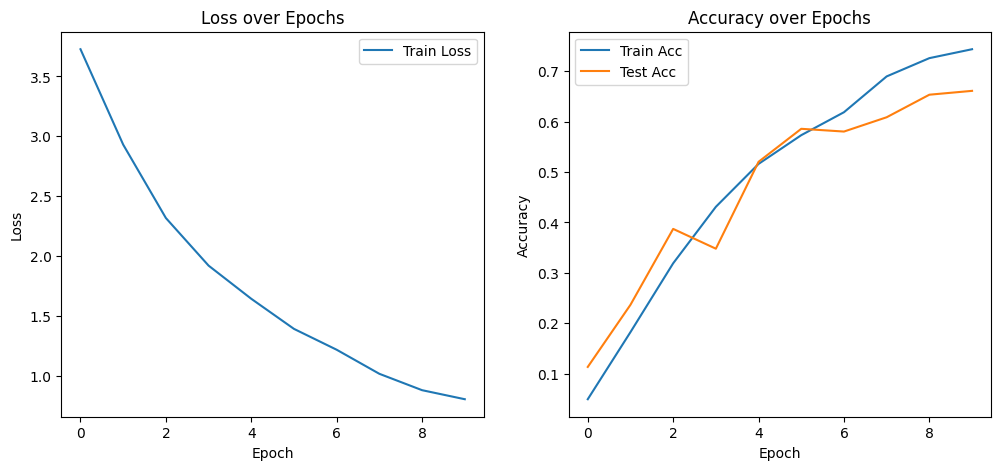

In [ ]:
# Plot Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()